## Measures of Central Tendency

These play a major role in Feature Engineering and EDA.

There are 3 measures of Central Tendency
1. Mean
2. Median
3. Mode

I am using Seaborn's 'tips' dataset to perform various statistical operations

In [46]:
import numpy as np
import seaborn as sns

tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [ ]:
## Mean example
print("The mean of total_bill:", np.mean(tips['total_bill']))
## Median
print(f"Median of tips given: {np.median(tips['tip'])}")

## Mode
# from scipy import stats
# print(f"The most visitors come on the day: {stats.mode(tips['day'])}")

print(f"The most visitors come on the day: {tips['day'].mode()[0]}")
# This is using the Pandas Series built-in method .mode() works with any data type.
# retuens a series of modes, although Sat is the only entry here, we need to give index [0]. There could be two or more days with equal max frequency, so it returns a series (not single value)

The mean of total_bill: 19.78594262295082
Median of tips given: 2.9
The most visitors come on the day: Sat


In [4]:
## We can also use value_counts() method also

print(f"Day with max visitors using value_counts: {tips['day'].value_counts().head(1)}")

Day with max visitors using value_counts: day
Sat    87
Name: count, dtype: int64


In [6]:
## Finding variance and standard deviation
print(f"The variance(spread) of total bill data is: {np.var(tips['total_bill'])}")
print(f"The standard variation (how far is this point away from the mean) of total bill data is: {np.std(tips['total_bill'])}")

The variance(spread) of total bill data is: 78.92813148851114
The standard variation (how far is this point away from the mean) of total bill data is: 8.884150577771132


In [17]:
## Using Pandas DataFrame
import pandas as pd

df = pd.DataFrame(tips)
print(f"The variance(spread) of total bill data using Pandas method is: {df['total_bill'].var()}")
print(f"The standard variation (how far is this point away from the mean) of total bill data is: {df['total_bill'].std()}")

The variance(spread) of total bill data using Pandas method is: 79.25293861397827
The standard variation (how far is this point away from the mean) of total bill data is: 8.902411954856856


In [45]:
## Finding covariance and correlation
## Using Numpy
print("Using Numpy library:")
print(f"Covariance between tip and total bill: \n{np.cov(tips['tip'], tips['total_bill'])}")
print(f"\nCorrelation between tip and total bill: \n{np.corrcoef(tips['tip'], tips['total_bill'])}")

print("\n\nUsing Pandas DF:")
print(f"Covariance matrix between tip and total bill: \n{tips[['tip', 'total_bill']].cov()}")
print(f"\nPearson Correlation matrix between tip and total bill: \n{tips[['tip', 'total_bill']].corr(method='pearson')}")
print(f"\nSpearman Correlation matrix between tip and total bill: \n{tips[['tip', 'total_bill']].corr(method='spearman')}")

print(f"\nPearson correlation between tip and total bill (Specified features): {tips['tip'].corr(tips['total_bill'], method='pearson')}")
print(f"\nSpearman between tip and total bill (Specified features): {tips['tip'].corr(tips['total_bill'], method='spearman')}")

Using Numpy library:
Covariance between tip and total bill: 
[[ 1.91445464  8.32350163]
 [ 8.32350163 79.25293861]]

Correlation between tip and total bill: 
[[1.         0.67573411]
 [0.67573411 1.        ]]


Using Pandas DF:
Covariance matrix between tip and total bill: 
                 tip  total_bill
tip         1.914455    8.323502
total_bill  8.323502   79.252939

Pearson Correlation matrix between tip and total bill: 
                 tip  total_bill
tip         1.000000    0.675734
total_bill  0.675734    1.000000

Spearman Correlation matrix between tip and total bill: 
                 tip  total_bill
tip         1.000000    0.678968
total_bill  0.678968    1.000000

Pearson correlation between tip and total bill (Specified features): 0.6757341092113643

Spearman between tip and total bill (Specified features): 0.6789681219001009


<Axes: >

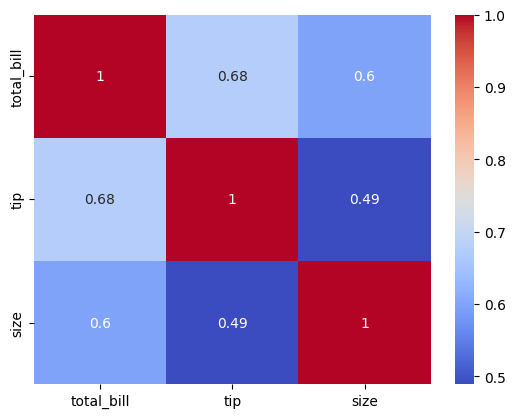

In [48]:
mycorr = tips[['total_bill','tip','size']].corr()
mycorr

## Heqtmap gives a colorful visualization
sns.heatmap(mycorr,annot=True,cmap='coolwarm')

### EXtra Points
1

To find mode of data we can use scipy modele's stats.mod() fucntion but it does not work with strings, only numeric data.

We can simply use pandas mode()

2

Missing value of categorical data can be filled by using mode.

Another way of finding max frequent datapoint is using value_counts() built-in method of Pandas.
value_counts() returns a sorted Series of unique values and their frequencies. These are sorted in descending order by default.

3

The values of variance and stamdard deviation are calculated differently by using Numpy methods vs Pandas method.
NumPy divides by n (population) as Numpy treats the dataset as population data.
Pandas divides by n−1 (sample) as Pandas is used for statistical analysis and by default considers the df as sample data.